**Loading the Dataset**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")

# Load data
df = pd.read_csv("/content/cleaned_sales_data.csv")

# Preview
df.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method,Year,Month,Day,Calculated Revenue,Revenue Difference
0,10001,2024-01-01,electronics,iphone 14 pro,2,999.99,1999.98,north america,credit card,2024,1,1,1999.98,0.000000e+00
1,10002,2024-01-02,home appliances,dyson v11 vacuum,1,499.99,499.99,europe,paypal,2024,1,2,499.99,0.000000e+00
2,10003,2024-01-03,clothing,levi's 501 jeans,3,69.99,209.97,asia,debit card,2024,1,3,209.97,2.842171e-14
3,10004,2024-01-04,books,the da vinci code,4,15.99,63.96,north america,credit card,2024,1,4,63.96,0.000000e+00
4,10005,2024-01-05,beauty products,neutrogena skincare set,1,89.99,89.99,europe,paypal,2024,1,5,89.99,0.000000e+00


**Basic infromation**

In [2]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nSummary Stats:")
print(df.describe())

Shape: (240, 14)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction ID      240 non-null    int64  
 1   Date                240 non-null    object 
 2   Product Category    240 non-null    object 
 3   Product Name        240 non-null    object 
 4   Units Sold          240 non-null    int64  
 5   Unit Price          240 non-null    float64
 6   Total Revenue       240 non-null    float64
 7   Region              240 non-null    object 
 8   Payment Method      240 non-null    object 
 9   Year                240 non-null    int64  
 10  Month               240 non-null    int64  
 11  Day                 240 non-null    int64  
 12  Calculated Revenue  240 non-null    float64
 13  Revenue Difference  240 non-null    float64
dtypes: float64(4), int64(5), object(5)
memory usage: 26.4+ KB
None

Summary Stats:
   

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

**Univatiate Analysis**\
**1. Numerical Distribution**

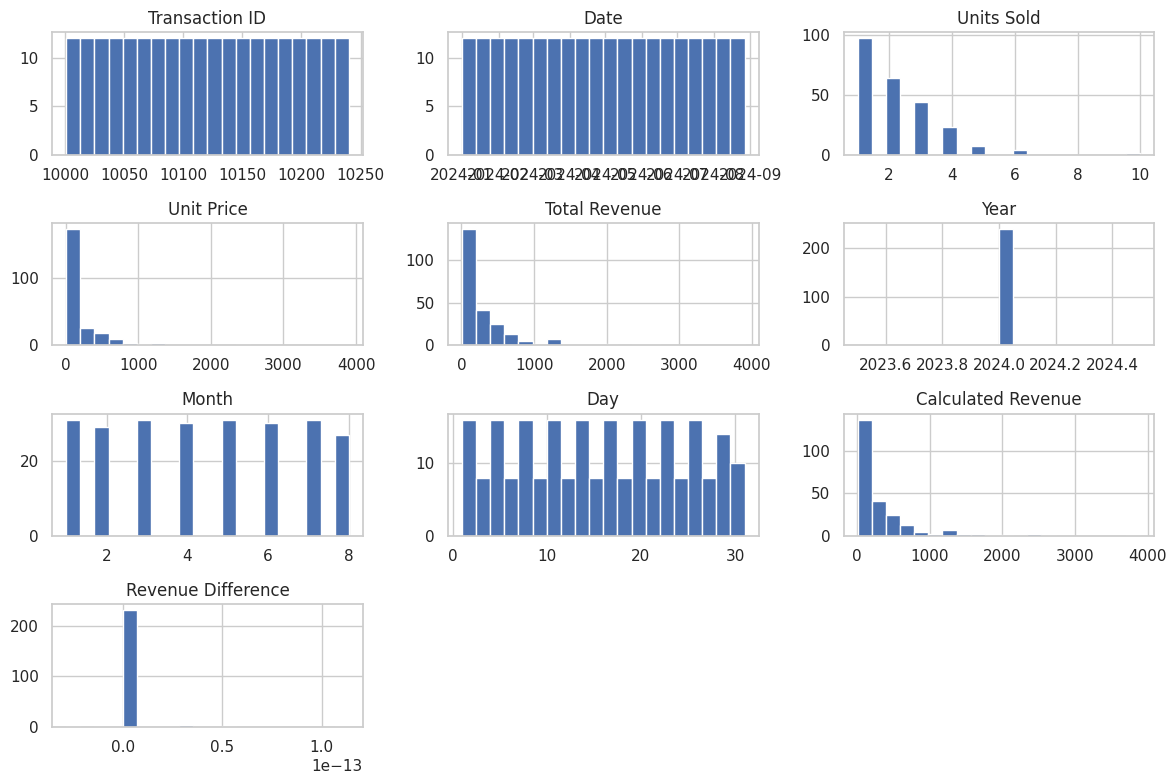

In [4]:
df.hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

**2. Product Category**

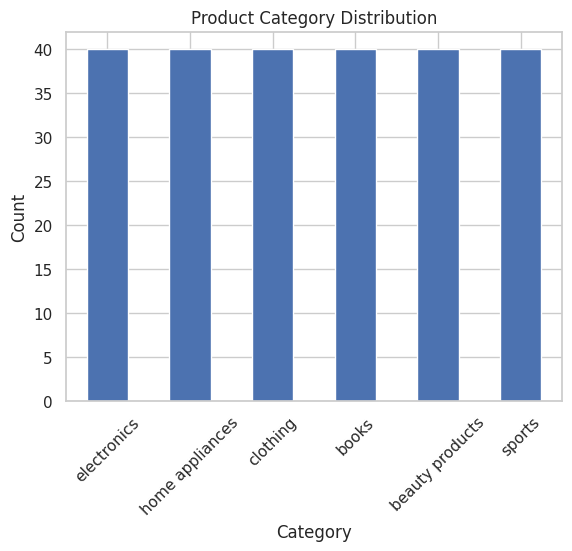

In [5]:
df['Product Category'].value_counts().plot(kind='bar')
plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**3. Region **

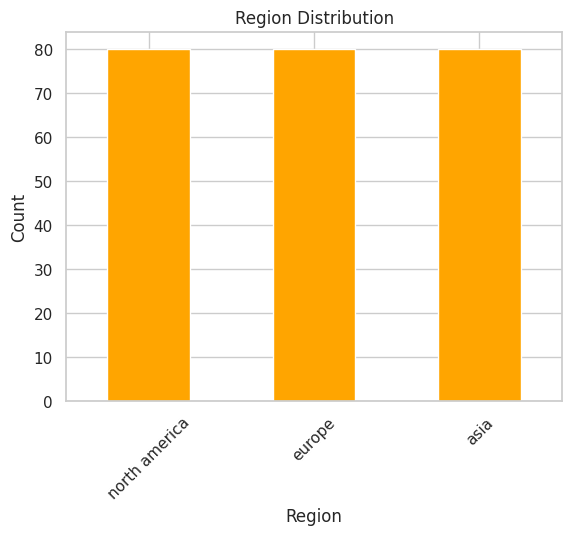

In [6]:
df['Region'].value_counts().plot(kind='bar', color='orange')
plt.title("Region Distribution")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**Business Questions**
1. What are the top 5 products by revenue?
2. Which category generates the most revenue?
3. Which region contributes the most sales?
4. What is the monthly sales trend?
5. What payment method is most used?
6. What is the average revenue per order?


1. What are the top 5 products by revenue?

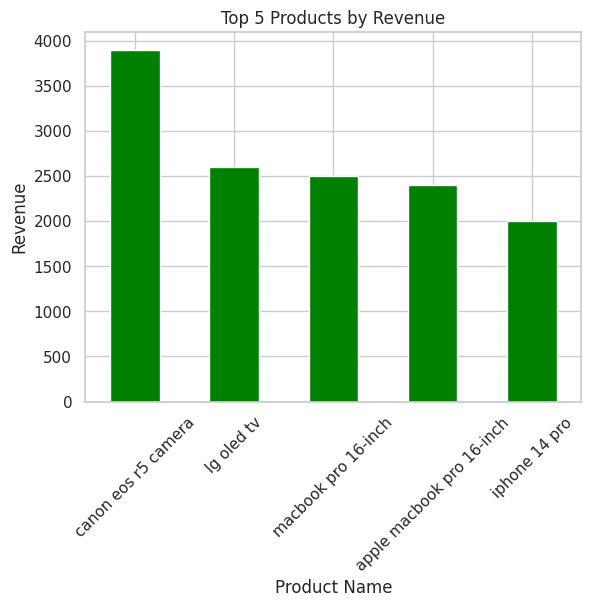

In [7]:

top_products = (
    df.groupby('Product Name')['Total Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_products.plot(kind='bar', color='green')
plt.title("Top 5 Products by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Product canon eos r5 camera generates the highest revenue, making it the top-performing product.

2. Which category generates the most revenue?

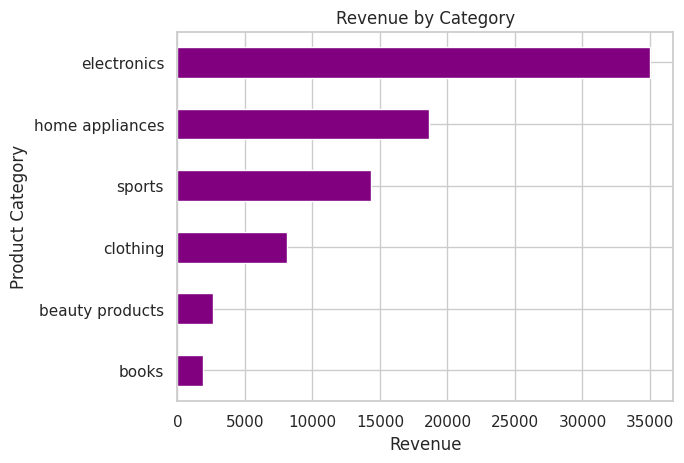

In [8]:
df.groupby('Product Category')['Total Revenue'] \
  .sum() \
  .sort_values() \
  .plot(kind='barh', color='purple')

plt.title("Revenue by Category")
plt.xlabel("Revenue")
plt.show()

The Electronics category appears most frequently, indicating it is the most sold product type.

3. What is the monthly sales trend?

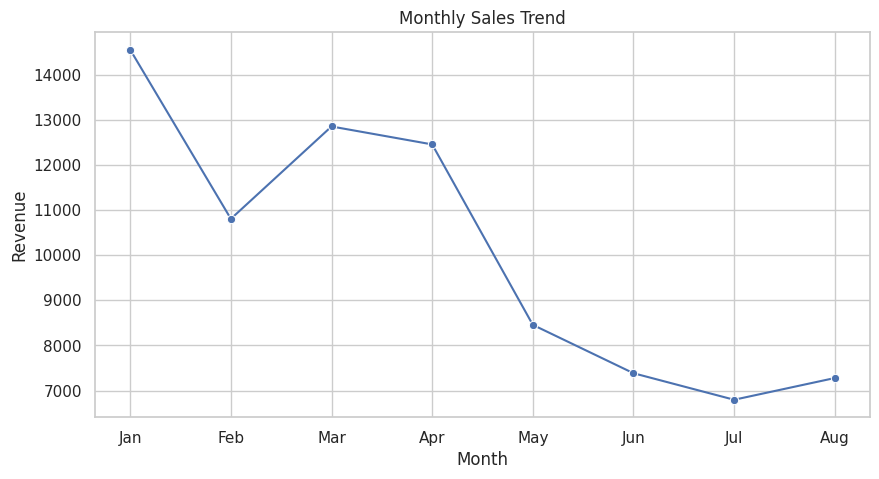

In [9]:
monthly_sales = (
    df.groupby(['Year', 'Month', 'Month_Name'])['Total Revenue']
    .sum()
    .reset_index()
    .sort_values(['Year', 'Month'])
)

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x='Month_Name', y='Total Revenue', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Sales peak in January, suggesting possible seasonal demand or promotional impact.

4. Which region contributes the most sales?

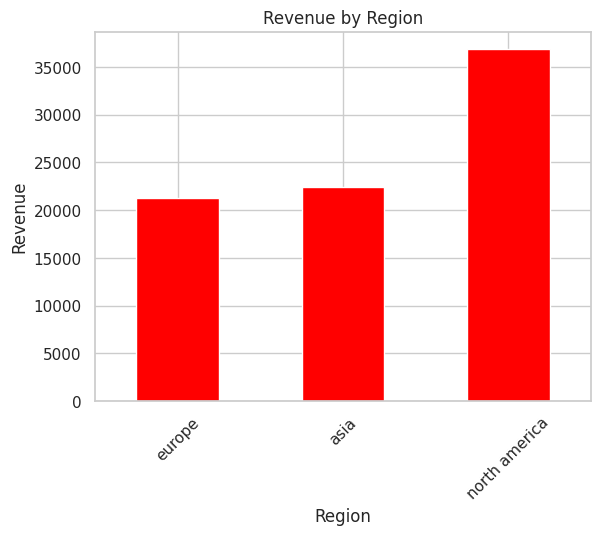

In [10]:
df.groupby('Region')['Total Revenue'] \
  .sum() \
  .sort_values() \
  .plot(kind='bar', color='red')

plt.title("Revenue by Region")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

5. What payment method is most used?

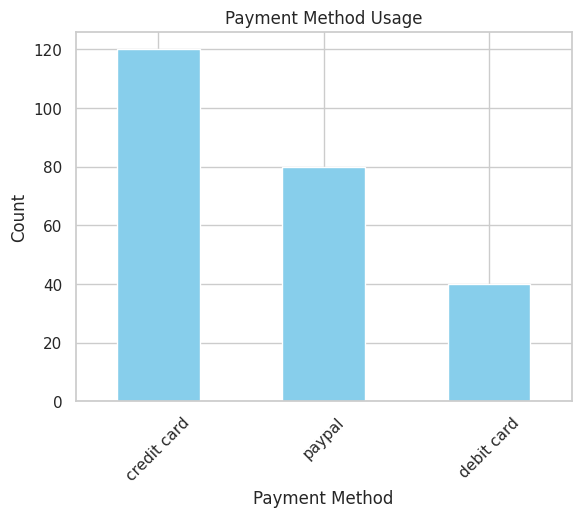

In [11]:
df['Payment Method'].value_counts().plot(kind='bar', color='skyblue')

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

6. What is the average revenue per order?

In [12]:
avg_revenue = df['Total Revenue'].mean()
print("Average Revenue:", avg_revenue)

Average Revenue: 335.699375


Multivariate Analysis

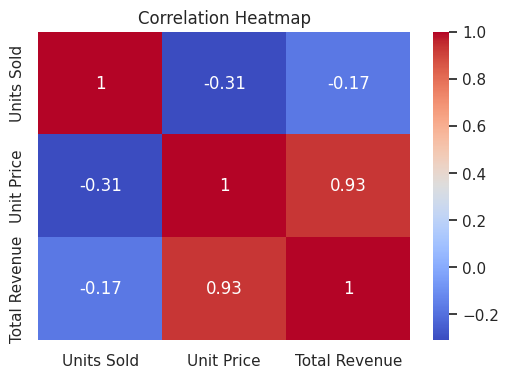

In [13]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[['Units Sold','Unit Price','Total Revenue']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

Total revenue is strongly correlated with units sold, indicating that sales volume drives revenue.

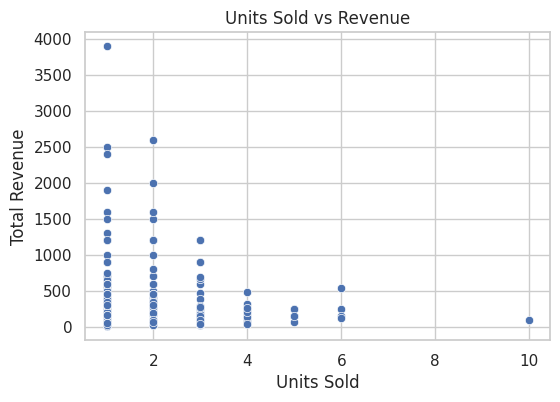

In [14]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='Units Sold',
    y='Total Revenue',
    data=df
)

plt.title("Units Sold vs Revenue")
plt.show()

Revenue Validation

In [15]:
if 'Revenue Difference' in df.columns:
    print(df['Revenue Difference'].describe())
else:
    print("Revenue Difference column not found")

count    2.400000e+02
mean     1.243450e-15
std      1.174171e-14
min     -2.842171e-14
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.136868e-13
Name: Revenue Difference, dtype: float64


In [16]:
total_revenue = df['Total Revenue'].sum()
avg_revenue = df['Total Revenue'].mean()
total_orders = df.shape[0]

print("Total Revenue:", total_revenue)
print("Average Revenue:", avg_revenue)
print("Total Orders:", total_orders)

Total Revenue: 80567.84999999999
Average Revenue: 335.699375
Total Orders: 240


**Key Insights**
- The top-performing product is canon eos r5 camera generates, generating the highest revenue.
- The electronic category contributes the most to overall sales.
- The North America region is the leading in revenue.
- Sales peak during January, indicating seasonal trends.
- Most customers prefer credit card.
- Revenue strongly depends on units sold.